## Use ffill or bfill
- ffill means forward fill
- bfill means backward fill
- This technique is well suited for time-series data, or any data that follows pattern that depends on previous/next data

In [8]:
import pandas as pd

import matplotlib.pyplot as plt

In [ ]:
# (SKIP) Simulated stock price data
# data = {
#     'Date': pd.date_range(start='2024-01-01', periods=16, freq='D'),
#     'StockPrice': [100, np.nan, 102, np.nan, np.nan, 105, 106, np.nan, 108, 
#                    np.nan, np.nan, 111, 113, np.nan, 115, np.nan]
# }


# df = pd.DataFrame(data)
# df.to_csv('missing_stock_price.csv', index=False)


In [3]:
# 1)
df = pd.read_csv('missing_stock_price.csv') # Here price feature could have been temperature
print(df)

          Date  StockPrice
0   2024-01-01       100.0
1   2024-01-02         NaN
2   2024-01-03       102.0
3   2024-01-04         NaN
4   2024-01-05         NaN
5   2024-01-06       105.0
6   2024-01-07       106.0
7   2024-01-08         NaN
8   2024-01-09       108.0
9   2024-01-10         NaN
10  2024-01-11         NaN
11  2024-01-12       111.0
12  2024-01-13       113.0
13  2024-01-14         NaN
14  2024-01-15       115.0
15  2024-01-16         NaN


In [4]:
# 2) ffill: This fills missing values with the LAST known valid price.

# df_copy = df.copy() # or work with a copy if needed

df['StockPrice_ffill'] = df['StockPrice'].ffill() 
print(df) # Forward Fill (ffill) applied

          Date  StockPrice  StockPrice_ffill
0   2024-01-01       100.0             100.0
1   2024-01-02         NaN             100.0
2   2024-01-03       102.0             102.0
3   2024-01-04         NaN             102.0
4   2024-01-05         NaN             102.0
5   2024-01-06       105.0             105.0
6   2024-01-07       106.0             106.0
7   2024-01-08         NaN             106.0
8   2024-01-09       108.0             108.0
9   2024-01-10         NaN             108.0
10  2024-01-11         NaN             108.0
11  2024-01-12       111.0             111.0
12  2024-01-13       113.0             113.0
13  2024-01-14         NaN             113.0
14  2024-01-15       115.0             115.0
15  2024-01-16         NaN             115.0


In [5]:
# 3) bfill: This fills missing values with the NEXT known valid price.

df['StockPrice_bfill'] = df['StockPrice'].bfill()
print("Backward Fill (bfill) applied:\n", df) 

Backward Fill (bfill) applied:
           Date  StockPrice  StockPrice_ffill  StockPrice_bfill
0   2024-01-01       100.0             100.0             100.0
1   2024-01-02         NaN             100.0             102.0
2   2024-01-03       102.0             102.0             102.0
3   2024-01-04         NaN             102.0             105.0
4   2024-01-05         NaN             102.0             105.0
5   2024-01-06       105.0             105.0             105.0
6   2024-01-07       106.0             106.0             106.0
7   2024-01-08         NaN             106.0             108.0
8   2024-01-09       108.0             108.0             108.0
9   2024-01-10         NaN             108.0             111.0
10  2024-01-11         NaN             108.0             111.0
11  2024-01-12       111.0             111.0             111.0
12  2024-01-13       113.0             113.0             113.0
13  2024-01-14         NaN             113.0             115.0
14  2024-01-15       11

In [6]:
# 4) (OPTIONAL) You can even combine both:

df['StockPrice_combine'] = df['StockPrice'].ffill().bfill()
print("Forward Fill then Backward Fill applied:\n", df)

Forward Fill then Backward Fill applied:
           Date  StockPrice  StockPrice_ffill  StockPrice_bfill  \
0   2024-01-01       100.0             100.0             100.0   
1   2024-01-02         NaN             100.0             102.0   
2   2024-01-03       102.0             102.0             102.0   
3   2024-01-04         NaN             102.0             105.0   
4   2024-01-05         NaN             102.0             105.0   
5   2024-01-06       105.0             105.0             105.0   
6   2024-01-07       106.0             106.0             106.0   
7   2024-01-08         NaN             106.0             108.0   
8   2024-01-09       108.0             108.0             108.0   
9   2024-01-10         NaN             108.0             111.0   
10  2024-01-11         NaN             108.0             111.0   
11  2024-01-12       111.0             111.0             111.0   
12  2024-01-13       113.0             113.0             113.0   
13  2024-01-14         NaN        

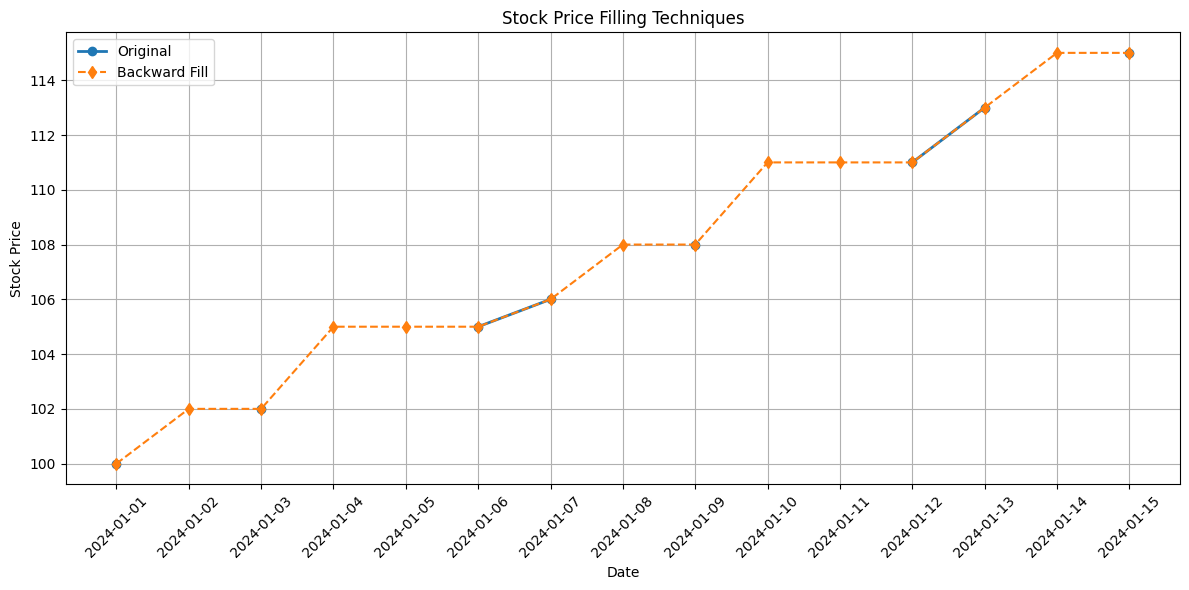

In [12]:
# 5) Plotting all versions. 

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['StockPrice'], 'o-', label='Original', linewidth=2)

# NOTE: comment each one out to see them
# plt.plot(df['Date'], df['StockPrice_ffill'], 's--', label='Forward Fill')
plt.plot(df['Date'], df['StockPrice_bfill'], 'd--', label='Backward Fill')
# plt.plot(df['Date'], df['StockPrice_combine'], '*-', label='Combined Fill') # OPTIONAL

plt.xticks(rotation=45)
plt.title('Stock Price Filling Techniques')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()